8


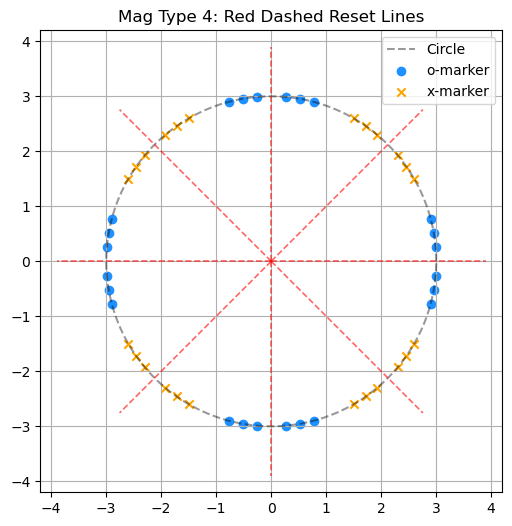

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# === Parameters ===
radius = 3
num_points = 3
theta_start = 5      # deg
theta_end = 15       # deg
mag_type = 4         # symmetry (2, 3, 4, ...)

# === Derived angles ===
reset_angle = np.pi / mag_type
reflect_angle = np.pi / (2 * mag_type)

# === Base arc points ===
theta = np.linspace(np.radians(theta_start), np.radians(theta_end), num_points)

x_base = radius * np.cos(theta)
y_base = radius * np.sin(theta)

# Rotates the points by the angle phi
def rotate_points(x, y, phi):
    x_rot = x * np.cos(phi) - y * np.sin(phi)
    y_rot = x * np.sin(phi) + y * np.cos(phi)
    return x_rot, y_rot

# Reflects points across the angle phi
def reflect_points(x, y, phi):
    x_ref = x * np.cos(2 * phi) + y * np.sin(2 * phi)
    y_ref = x * np.sin(2 * phi) - y * np.cos(2 * phi)
    return x_ref, y_ref

marker_styles = ['o', 'x']
marker_colors = {'o': 'dodgerblue', 'x': 'orange'}

plt.figure(figsize=(6, 6))

# Circle outline
phi_circle = np.linspace(0, 2 * np.pi, 400)
plt.plot(radius * np.cos(phi_circle), radius * np.sin(phi_circle), 'k--', alpha=0.4, label='Circle')

num_blocks = 2*mag_type

print(num_blocks)

for j in range(num_blocks):
    block_start = j * reset_angle
    mid_axis = block_start + reflect_angle

    # alternate markers each block
    base_marker = marker_styles[j % 2]
    refl_marker = marker_styles[(j + 1) % 2]

    # rotate base arc into this block
    xr, yr = rotate_points(x_base, y_base, block_start)
    plt.scatter(xr, yr, marker=base_marker, color=marker_colors[base_marker], label=f"{base_marker}-marker" if j == 0 else "")

    # reflect across mid-axis of this block
    xr_ref, yr_ref = reflect_points(xr, yr, mid_axis)
    plt.scatter(xr_ref, yr_ref, marker=refl_marker, color=marker_colors[refl_marker], label=f"{refl_marker}-marker" if j == 0 else "")

    # draw red dashed reset line
    axis_len = radius * 1.3
    plt.plot([0, axis_len * np.cos(block_start)], [0, axis_len * np.sin(block_start)], 'r--', alpha=0.6, linewidth=1.2)

plt.gca().set_aspect('equal', adjustable='box')
plt.xlim(-radius * 1.4, radius * 1.4)
plt.ylim(-radius * 1.4, radius * 1.4)
plt.grid(True)
plt.legend()
plt.title(f"Mag Type {mag_type}: Red Dashed Reset Lines")
plt.show()
